In [1]:
# ==============================================================================
# CELDA 1: IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelo SVM
from sklearn.svm import SVC

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# ==============================================================================
# CELDA 2: CARGA Y EXPLORACIÓN DEL DATASET SONAR
# ==============================================================================
# Dataset: Sonar Mines vs Rocks
# Objetivo: Clasificar si un objeto detectado por sonar es una mina o una roca

print("="*80)
print("CARGA Y EXPLORACIÓN DEL DATASET SONAR")
print("="*80)

# ----- 1. CARGAR DATASET -----
print("\n📂 Paso 1: Cargando dataset...")

url = "https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Sonar%20Mine%20Rock%20Data.csv"
df = pd.read_csv(url)

print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# ----- 2. PRIMERAS FILAS -----
print(f"\n📋 Primeras 5 filas del dataset:")
print(df.head())

# ----- 3. INFORMACIÓN GENERAL -----
print(f"\n📊 Información del dataset:")
print(df.info())

# ----- 4. ESTADÍSTICAS DESCRIPTIVAS -----
print(f"\n📈 Estadísticas descriptivas:")
print(df.describe())

# ----- 5. VALORES NULOS -----
print(f"\n🔍 Valores nulos por columna:")
nulos = df.isnull().sum()
print(f"   Total de valores nulos: {nulos.sum()}")

# ----- 6. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO -----
print(f"\n🎯 Distribución de la variable objetivo:")
print(df.iloc[:, -1].value_counts())
print(f"\nProporción:")
print(df.iloc[:, -1].value_counts(normalize=True).round(4))

print("\n" + "="*80)

CARGA Y EXPLORACIÓN DEL DATASET SONAR

📂 Paso 1: Cargando dataset...
✅ Dataset cargado exitosamente
   Dimensiones: 208 filas × 61 columnas

📋 Primeras 5 filas del dataset:
       X1      X2      X3      X4      X5      X6      X7      X8      X9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

      X10  ...     X52     X53     X54     X55     X56     X57     X58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.00

In [3]:
# ==============================================================================
# CELDA 3: PREPROCESAMIENTO DE DATOS
# ==============================================================================
# El SVM es muy sensible a la escala de los datos, por lo que la
# normalización es un paso CRÍTICO y obligatorio antes de entrenar

print("="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)

# ----- 1. SEPARAR FEATURES Y TARGET -----
print(f"\n🔧 Paso 1: Separando features (X) y target (y)...")

# Las primeras 60 columnas son las features (señales de sonar)
X = df.iloc[:, :-1]

# La última columna es la variable objetivo (M=Mina, R=Roca)
y = df.iloc[:, -1]

print(f"✅ Separación completada:")
print(f"   X (Features): {X.shape[0]} filas × {X.shape[1]} columnas")
print(f"   y (Target): {y.shape[0]} valores")
print(f"   Clases: {y.unique()}")

# ----- 2. CODIFICAR VARIABLE OBJETIVO -----
print(f"\n🔧 Paso 2: Codificando variable objetivo...")

# Convertir M (Mine) y R (Rock) a valores numéricos
# M → 1 (Mina), R → 0 (Roca)
y_encoded = y.map({'M': 1, 'R': 0})

print(f"✅ Variable objetivo codificada:")
print(f"   R (Rock)  → 0")
print(f"   M (Mine)  → 1")

# ----- 3. DIVIDIR EN TRAIN Y TEST -----
print(f"\n🔧 Paso 3: Dividiendo dataset en entrenamiento y prueba...")

# División 80% entrenamiento, 20% prueba
# stratify=y_encoded asegura misma proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,      # 20% para prueba
    random_state=42,    # Semilla para reproducibilidad
    stratify=y_encoded  # Mantener proporción de clases
)

print(f"✅ Dataset dividido:")
print(f"   Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# ----- 4. NORMALIZACIÓN DE DATOS -----
print(f"\n🔧 Paso 4: Normalizando datos con StandardScaler...")

# IMPORTANTE: StandardScaler es esencial para SVM porque:
# - SVM calcula distancias entre puntos (hiperplano separador)
# - Si las features tienen escalas muy distintas, las de mayor escala
#   dominarán el cálculo de distancias y el modelo será sesgado
# - Con normalización, todas las features contribuyen por igual

scaler = StandardScaler()

# Ajustar el scaler SOLO con los datos de entrenamiento (evitar data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

print(f"✅ Datos normalizados:")
print(f"   Media entrenamiento (debe ser ~0): {X_train_scaled.mean():.6f}")
print(f"   Desviación estándar (debe ser ~1): {X_train_scaled.std():.6f}")

print("\n" + "="*80)
print("✅ PREPROCESAMIENTO COMPLETADO")
print("="*80)

PREPROCESAMIENTO DE DATOS

🔧 Paso 1: Separando features (X) y target (y)...
✅ Separación completada:
   X (Features): 208 filas × 60 columnas
   y (Target): 208 valores
   Clases: ['R' 'M']

🔧 Paso 2: Codificando variable objetivo...
✅ Variable objetivo codificada:
   R (Rock)  → 0
   M (Mine)  → 1

🔧 Paso 3: Dividiendo dataset en entrenamiento y prueba...
✅ Dataset dividido:
   Entrenamiento: 166 muestras (79.8%)
   Prueba:        42 muestras (20.2%)

🔧 Paso 4: Normalizando datos con StandardScaler...
✅ Datos normalizados:
   Media entrenamiento (debe ser ~0): -0.000000
   Desviación estándar (debe ser ~1): 1.000000

✅ PREPROCESAMIENTO COMPLETADO


In [4]:
# ==============================================================================
# CELDA 4: CONSTRUIR Y ENTRENAR EL MODELO SVM
# ==============================================================================
# Kernel elegido: RBF (Radial Basis Function)
#
# ¿Por qué RBF?
# El dataset Sonar tiene 60 features con relaciones complejas y no lineales
# entre ellas (señales de energía acústica rebotadas). El kernel RBF es capaz
# de separar clases que NO son linealmente separables mapeando los datos a un
# espacio de dimensiones superiores, lo que lo hace ideal para este problema.
# Además, es el kernel más robusto y versátil en la práctica, especialmente
# cuando no se conoce la naturaleza exacta de los datos de antemano.

print("="*80)
print("ENTRENAMIENTO DEL MODELO SVM (Kernel RBF)")
print("="*80)

# ----- 1. CREAR EL MODELO -----
print(f"\n🔧 Paso 1: Creando modelo SVM con kernel RBF...")

svm_model = SVC(
    kernel='rbf',       # Kernel RBF: ideal para datos no linealmente separables
    C=1.0,              # Parámetro de regularización: balance entre margen y errores
    gamma='scale',      # Coeficiente del kernel: 'scale' = 1/(n_features * X.var())
    random_state=42     # Semilla para reproducibilidad
)

print(f"✅ Modelo creado con parámetros:")
print(f"   • Kernel:  {svm_model.kernel}")
print(f"   • C:       {svm_model.C}")
print(f"   • Gamma:   {svm_model.gamma}")

# ----- 2. ENTRENAR EL MODELO -----
print(f"\n🏋️ Paso 2: Entrenando el modelo...")

svm_model.fit(X_train_scaled, y_train)

print(f"✅ Modelo entrenado exitosamente")
print(f"\n📊 Información del modelo entrenado:")
print(f"   • Número de vectores de soporte: {svm_model.n_support_}")
print(f"   • Total vectores de soporte:     {sum(svm_model.n_support_)}")
print(f"   • Clases detectadas:             {svm_model.classes_}")

# ----- 3. HACER PREDICCIONES -----
print(f"\n🔮 Paso 3: Realizando predicciones...")

# Predicciones en entrenamiento
y_train_pred = svm_model.predict(X_train_scaled)

# Predicciones en prueba
y_test_pred = svm_model.predict(X_test_scaled)

print(f"✅ Predicciones realizadas:")
print(f"   • Predicciones en entrenamiento: {len(y_train_pred)}")
print(f"   • Predicciones en prueba:        {len(y_test_pred)}")

# Mostrar ejemplo de predicciones
print(f"\n📋 Ejemplo de predicciones (primeras 10 muestras de test):")
ejemplo = pd.DataFrame({
    'Real':     y_test[:10].values,
    'Predicho': y_test_pred[:10]
})
ejemplo['Real_Label']     = ejemplo['Real'].map({0: 'Roca (R)', 1: 'Mina (M)'})
ejemplo['Predicho_Label'] = ejemplo['Predicho'].map({0: 'Roca (R)', 1: 'Mina (M)'})
ejemplo['Correcto'] = ejemplo['Real'] == ejemplo['Predicho']
print(ejemplo)

print("\n" + "="*80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("="*80)

ENTRENAMIENTO DEL MODELO SVM (Kernel RBF)

🔧 Paso 1: Creando modelo SVM con kernel RBF...
✅ Modelo creado con parámetros:
   • Kernel:  rbf
   • C:       1.0
   • Gamma:   scale

🏋️ Paso 2: Entrenando el modelo...
✅ Modelo entrenado exitosamente

📊 Información del modelo entrenado:
   • Número de vectores de soporte: [60 67]
   • Total vectores de soporte:     127
   • Clases detectadas:             [0 1]

🔮 Paso 3: Realizando predicciones...
✅ Predicciones realizadas:
   • Predicciones en entrenamiento: 166
   • Predicciones en prueba:        42

📋 Ejemplo de predicciones (primeras 10 muestras de test):
   Real  Predicho Real_Label Predicho_Label  Correcto
0     1         1   Mina (M)       Mina (M)      True
1     1         1   Mina (M)       Mina (M)      True
2     1         1   Mina (M)       Mina (M)      True
3     1         1   Mina (M)       Mina (M)      True
4     0         0   Roca (R)       Roca (R)      True
5     0         1   Roca (R)       Mina (M)     False
6     0   

In [5]:
# ==============================================================================
# CELDA 5: MÉTRICAS DE EVALUACIÓN DEL MODELO SVM
# ==============================================================================

print("="*80)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO SVM")
print("="*80)

# ----- 1. MÉTRICAS EN ENTRENAMIENTO -----
print(f"\n📊 MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO:")
print("-"*80)

train_accuracy  = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall    = recall_score(y_train, y_train_pred)
train_f1        = f1_score(y_train, y_train_pred)

print(f"   • Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   • Precision: {train_precision:.4f}")
print(f"   • Recall:    {train_recall:.4f}")
print(f"   • F1-Score:  {train_f1:.4f}")

# ----- 2. MÉTRICAS EN PRUEBA -----
print(f"\n📊 MÉTRICAS EN CONJUNTO DE PRUEBA:")
print("-"*80)

test_accuracy  = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall    = recall_score(y_test, y_test_pred)
test_f1        = f1_score(y_test, y_test_pred)

print(f"   • Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Precision: {test_precision:.4f}")
print(f"   • Recall:    {test_recall:.4f}")
print(f"   • F1-Score:  {test_f1:.4f}")

# ----- 3. COMPARACIÓN TRAIN VS TEST -----
print(f"\n📊 COMPARACIÓN ENTRENAMIENTO VS PRUEBA:")
print("-"*80)

comparison = pd.DataFrame({
    'Métrica':        ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Entrenamiento':  [train_accuracy, train_precision, train_recall, train_f1],
    'Prueba':         [test_accuracy, test_precision, test_recall, test_f1],
    'Diferencia':     [
        train_accuracy  - test_accuracy,
        train_precision - test_precision,
        train_recall    - test_recall,
        train_f1        - test_f1
    ]
})
comparison['Diferencia %'] = (comparison['Diferencia'] * 100).round(2)
print(comparison.to_string(index=False))

# Detectar overfitting
if (train_accuracy - test_accuracy) > 0.05:
    print(f"\n⚠️ Posible overfitting (diferencia train-test > 5%)")
else:
    print(f"\n✅ El modelo generaliza bien (diferencia train-test < 5%)")

# ----- 4. REPORTE COMPLETO -----
print(f"\n📋 REPORTE DE CLASIFICACIÓN DETALLADO (CONJUNTO DE PRUEBA):")
print("-"*80)
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Roca (R)', 'Mina (M)'],
    digits=4
))

print("="*80)

MÉTRICAS DE EVALUACIÓN DEL MODELO SVM

📊 MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO:
--------------------------------------------------------------------------------
   • Accuracy:  0.9699 (96.99%)
   • Precision: 1.0000
   • Recall:    0.9438
   • F1-Score:  0.9711

📊 MÉTRICAS EN CONJUNTO DE PRUEBA:
--------------------------------------------------------------------------------
   • Accuracy:  0.9286 (92.86%)
   • Precision: 0.8800
   • Recall:    1.0000
   • F1-Score:  0.9362

📊 COMPARACIÓN ENTRENAMIENTO VS PRUEBA:
--------------------------------------------------------------------------------
  Métrica  Entrenamiento   Prueba  Diferencia  Diferencia %
 Accuracy       0.969880 0.928571    0.041308          4.13
Precision       1.000000 0.880000    0.120000         12.00
   Recall       0.943820 1.000000   -0.056180         -5.62
 F1-Score       0.971098 0.936170    0.034928          3.49

✅ El modelo generaliza bien (diferencia train-test < 5%)

📋 REPORTE DE CLASIFICACIÓN DETALLADO (CON

MATRIZ DE CONFUSIÓN

                    Predicho
                Roca (0)  Mina (1)
Real   Roca (0)      17         3
       Mina (1)       0        22

Desglose:
   • True Negatives  (TN): 17 - Rocas clasificadas correctamente  ✅
   • True Positives  (TP): 22 - Minas clasificadas correctamente  ✅
   • False Positives (FP): 3 - Rocas clasificadas como minas     ❌
   • False Negatives (FN): 0 - Minas clasificadas como rocas     ❌


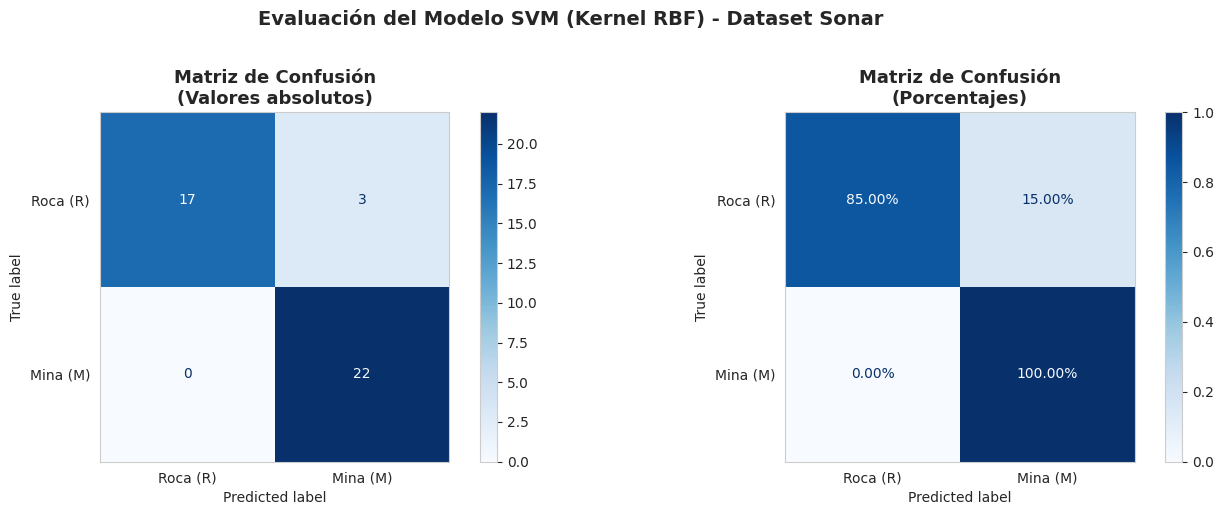


✅ Matriz de confusión generada


In [6]:
# ==============================================================================
# CELDA 6: MATRIZ DE CONFUSIÓN
# ==============================================================================

print("="*80)
print("MATRIZ DE CONFUSIÓN")
print("="*80)

# ----- 1. CALCULAR MATRIZ DE CONFUSIÓN -----
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

# ----- 2. MOSTRAR VALORES -----
print(f"\n                    Predicho")
print(f"                Roca (0)  Mina (1)")
print(f"Real   Roca (0)  {tn:6d}    {fp:6d}")
print(f"       Mina (1)  {fn:6d}    {tp:6d}")

print(f"\nDesglose:")
print(f"   • True Negatives  (TN): {tn} - Rocas clasificadas correctamente  ✅")
print(f"   • True Positives  (TP): {tp} - Minas clasificadas correctamente  ✅")
print(f"   • False Positives (FP): {fp} - Rocas clasificadas como minas     ❌")
print(f"   • False Negatives (FN): {fn} - Minas clasificadas como rocas     ❌")

# ----- 3. VISUALIZACIÓN -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Valores absolutos
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Roca (R)', 'Mina (M)']
)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión\n(Valores absolutos)', fontsize=13, fontweight='bold')
axes[0].grid(False)

# Subplot 2: Valores normalizados (porcentajes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=['Roca (R)', 'Mina (M)']
)
disp_norm.plot(ax=axes[1], cmap='Blues', values_format='.2%')
axes[1].set_title('Matriz de Confusión\n(Porcentajes)', fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.suptitle('Evaluación del Modelo SVM (Kernel RBF) - Dataset Sonar',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Matriz de confusión generada")
print("="*80)